# Estadísticas de aviación comercial

Contiene información sobre el número de vuelos nationales e internacionales y el número de pasajerons movilizados meses antes y después de la pandemia de COVID-19

In [138]:
import pandas as pd

In [139]:
df = pd.read_csv('datos/Commercial_Aviation_Departures.csv')
df

,Mode,Indicator,Date,Week Num,Lowest,Current,Last Year
0,Aviation,U.S. Domestic Commercial Flights (Departures),08/01/2021,32.21,6679.0,23553,26791
1,Aviation,U.S. Domestic Commercial Flights (Departures),08/02/2021,32.21,6679.0,23840,28337
2,Aviation,U.S. Domestic Commercial Flights (Departures),08/03/2021,32.21,6679.0,23705,28660
3,Aviation,U.S. Domestic Commercial Flights (Departures),08/04/2021,32.21,6679.0,24411,27821
4,Aviation,U.S. Domestic Commercial Flights (Departures),08/05/2021,32.21,6679.0,25241,29244
...,...,...,...,...,...,...,...
2436,Aviation,U.S. International Commercial Flights (Departu...,03/23/2021,13.21,326.0,1679,4150
2437,Aviation,U.S. International Commercial Flights (Departu...,03/24/2021,13.21,326.0,1824,4347
2438,Aviation,U.S. International Commercial Flights (Departu...,03/25/2021,13.21,326.0,1895,4448
2439,Aviation,U.S. International Commercial Flights (Departu...,03/26/2021,13.21,326.0,1970,4517


In [140]:
print(df['Date'].min())
print(df['Date'].max())

01/01/2020
12/31/2021


## Preprocesamiento y preparación de los datos

In [141]:
df.index = pd.to_datetime(df['Date'])
df

,Mode,Indicator,Date,Week Num,Lowest,Current,Last Year
Date,,,,,,,
2021-08-01,Aviation,U.S. Domestic Commercial Flights (Departures),08/01/2021,32.21,6679.0,23553,26791
2021-08-02,Aviation,U.S. Domestic Commercial Flights (Departures),08/02/2021,32.21,6679.0,23840,28337
2021-08-03,Aviation,U.S. Domestic Commercial Flights (Departures),08/03/2021,32.21,6679.0,23705,28660
2021-08-04,Aviation,U.S. Domestic Commercial Flights (Departures),08/04/2021,32.21,6679.0,24411,27821
2021-08-05,Aviation,U.S. Domestic Commercial Flights (Departures),08/05/2021,32.21,6679.0,25241,29244
...,...,...,...,...,...,...,...
2021-03-23,Aviation,U.S. International Commercial Flights (Departu...,03/23/2021,13.21,326.0,1679,4150
2021-03-24,Aviation,U.S. International Commercial Flights (Departu...,03/24/2021,13.21,326.0,1824,4347
2021-03-25,Aviation,U.S. International Commercial Flights (Departu...,03/25/2021,13.21,326.0,1895,4448


In [142]:
df = df.drop(columns=['Mode', 'Date', 'Week Num', 'Lowest'])
df

,Indicator,Current,Last Year
Date,,,
2021-08-01,U.S. Domestic Commercial Flights (Departures),23553,26791
2021-08-02,U.S. Domestic Commercial Flights (Departures),23840,28337
2021-08-03,U.S. Domestic Commercial Flights (Departures),23705,28660
2021-08-04,U.S. Domestic Commercial Flights (Departures),24411,27821
2021-08-05,U.S. Domestic Commercial Flights (Departures),25241,29244
...,...,...,...
2021-03-23,U.S. International Commercial Flights (Departu...,1679,4150
2021-03-24,U.S. International Commercial Flights (Departu...,1824,4347
2021-03-25,U.S. International Commercial Flights (Departu...,1895,4448


In [143]:
df['Indicator'].value_counts()

Indicator
U.S. Domestic Commercial Flights (Departures)         823
People Screened at All Airports                       809
U.S. International Commercial Flights (Departures)    809
Name: count, dtype: int64

In [144]:
grupos = df.groupby(['Indicator', df.index]).sum()
grupos

Current  \
Indicator                                          Date                  
People Screened at All Airports                    2020-01-01  2155574   
                                                   2020-01-02  2415487   
                                                   2020-01-03  2334637   
                                                   2020-01-04  2198836   
                                                   2020-01-05  2445607   
...                                                                ...   
U.S. International Commercial Flights (Departures) 2022-03-22     3032   
                                                   2022-03-23     3088   
                                                   2022-03-24     3192   
                                                   2022-03-25     3249   
                                                   2022-03-26     3691   

                                                               Last Year  
Indicator                                          Date                   
People Screened at All Airports                    2020-01-01    2354510  
                                                   2020-01-02    2211239  
                                                   2020-01-03    2160942  
                                                   2020-01-04    1986061  
                                                   2020-01-05    2231586  
...                                                                  ...  
U.S. International Commercial Flights (Departures) 2022-03-22       4150  
                                                   2022-03-23       4347  
                                                   2022-03-24       4448  
                                                   2022-03-25       4517  
                                                   2022-03-26       4900  

[2433 rows x 2 columns]

### Nombre de las series por separado - usando un diccionario

In [145]:
nombres = grupos.index.get_level_values('Indicator').unique()
nombres

Index(['People Screened at All Airports',
       'U.S. Domestic Commercial Flights (Departures)',
       'U.S. International Commercial Flights (Departures)'],
      dtype='str', name='Indicator')

In [146]:
series = {}
for nombre in nombres:
    serie = grupos.xs(nombre, level='Indicator').sort_index()
    series[nombre] = serie 

series['U.S. International Commercial Flights (Departures)']

,Current,Last Year
Date,,
2020-01-01,4241,4709
2020-01-02,4553,4645
2020-01-03,4621,4727
2020-01-04,4991,5026
2020-01-05,4703,4636
...,...,...
2022-03-22,3032,4150
2022-03-23,3088,4347
2022-03-24,3192,4448


#### Teniendo las series en un diccionario se puede verificar su integridad

##### Indices de los registros

In [147]:
for key, value in series.items():
    print(f'\n{key}: {len(series[key])}')
    print(f'Inicio: {series[key].index.min()}')
    print(f'Final : {series[key].index.max()}')

# Las fechas son las mismas, pero se tienen diferentes longitudes
# Posiblemente hay marcas de tiempo faltantes


People Screened at All Airports: 808
Inicio: 2020-01-01 00:00:00
Final : 2022-03-26 00:00:00

U.S. Domestic Commercial Flights (Departures): 816
Inicio: 2020-01-01 00:00:00
Final : 2022-03-26 00:00:00

U.S. International Commercial Flights (Departures): 809
Inicio: 2020-01-01 00:00:00
Final : 2022-03-26 00:00:00


##### Datos faltantes

In [148]:
for key, value in series.items():
    faltan = series[key].isna().sum()
    print(f"\nFaltantes en '{key}':")
    print(f'{faltan}')

# No se cuenta con datos faltantes, para cada indice en la serie, se cuenta con un valor


Faltantes en 'People Screened at All Airports':
Current      0
Last Year    0
dtype: int64

Faltantes en 'U.S. Domestic Commercial Flights (Departures)':
Current      0
Last Year    0
dtype: int64

Faltantes en 'U.S. International Commercial Flights (Departures)':
Current      0
Last Year    0
dtype: int64


##### Marcas de tiempo faltantes

In [149]:
for key, value in series.items():
    serie = series[key]

    # Rango completo de las fechas ideales
    rango_completo = pd.date_range(start = serie.index.min(), end = serie.index.max(), freq = 'D')

    # Reindexar con un ranfo que está completo
    serie_reindex = serie.reindex(rango_completo)

    # me puede generar valores nan en la serie
    nfaltantes = serie_reindex.isna().sum()
    print(f"Marcas de tiempo faltantes en '{key}':")
    print(f'{nfaltantes}')

# Hay precencia de valores faltanres NAN en dos sereis de tiempo

Marcas de tiempo faltantes en 'People Screened at All Airports':
Current      8
Last Year    8
dtype: int64
Marcas de tiempo faltantes en 'U.S. Domestic Commercial Flights (Departures)':
Current      0
Last Year    0
dtype: int64
Marcas de tiempo faltantes en 'U.S. International Commercial Flights (Departures)':
Current      7
Last Year    7
dtype: int64


Ubicación de las marcas de tiempo faltantes

> People

DatetimeIndex(['2020-02-29', '2021-06-13', '2021-06-14', '2021-06-15',
               '2021-06-16', '2021-06-17', '2021-06-18', '2021-06-19'],
              dtype='datetime64[us]', freq=None)


<Axes: xlabel='Date'>

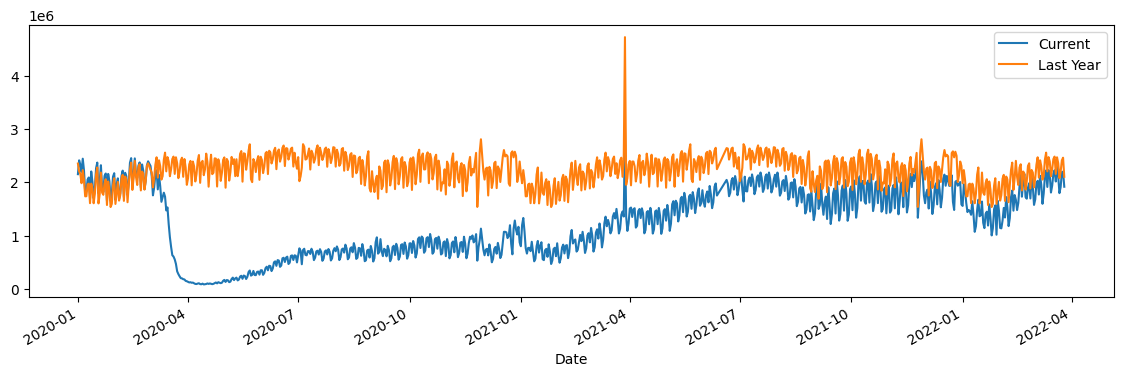

In [150]:
serie_pasajeros = series['People Screened at All Airports']
rango_psj = pd.date_range(start = serie_pasajeros.index.min(), end = serie_pasajeros.index.max(), freq = 'D')
print(rango_psj.difference(serie_pasajeros.index))

serie_pasajeros.plot(figsize = (14, 4))

# Como no hay valores extremos se puede interpolar esos valroes faltantes

Interpolación de los valores faltantes ubicados

In [151]:
#Agregarle sus fehas faltantes y se generan NAN
serie_pasajeros = serie_pasajeros.reindex(rango_psj)

# Imputando los NAN generados
serie_pasajeros['Current'] = serie_pasajeros['Current'].interpolate(methond = 'linear')
serie_pasajeros['Last Year'] = serie_pasajeros['Last Year'].interpolate(methond = 'linear')

print(serie_pasajeros.isna().sum())
print(len(serie_pasajeros))

Current      0
Last Year    0
dtype: int64
816


> Domestico

DatetimeIndex([], dtype='datetime64[us]', freq='D')


<Axes: xlabel='Date'>

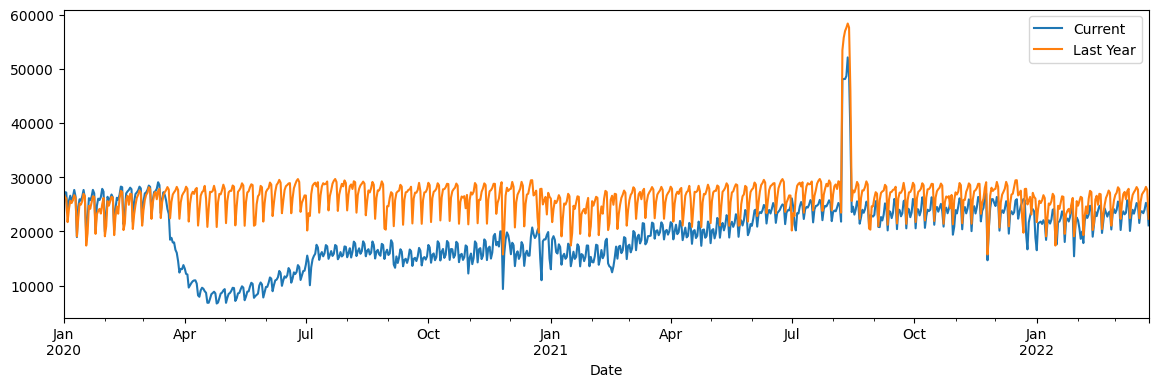

In [152]:
serie_dom = series['U.S. Domestic Commercial Flights (Departures)']
rango_dom = pd.date_range(start = serie_dom.index.min(), end=serie_dom.index.max(), freq = 'D')
print(rango_dom.difference(serie_dom.index))

serie_dom.plot(figsize = (14,4))

In [153]:
serie_dom = serie_dom.reindex(rango_dom)

serie_dom['Current'] = serie_dom['Current'].interpolate(method='nearest')
serie_dom['Last Year'] = serie_dom['Last Year'].interpolate(method = 'nearest')

print(serie_dom.isna().sum())
print(len(serie_dom))

Current      0
Last Year    0
dtype: int64
816


> Internacional

DatetimeIndex(['2021-08-08', '2021-08-09', '2021-08-10', '2021-08-11',
               '2021-08-12', '2021-08-13', '2021-08-14'],
              dtype='datetime64[us]', freq='D')


<Axes: xlabel='Date'>

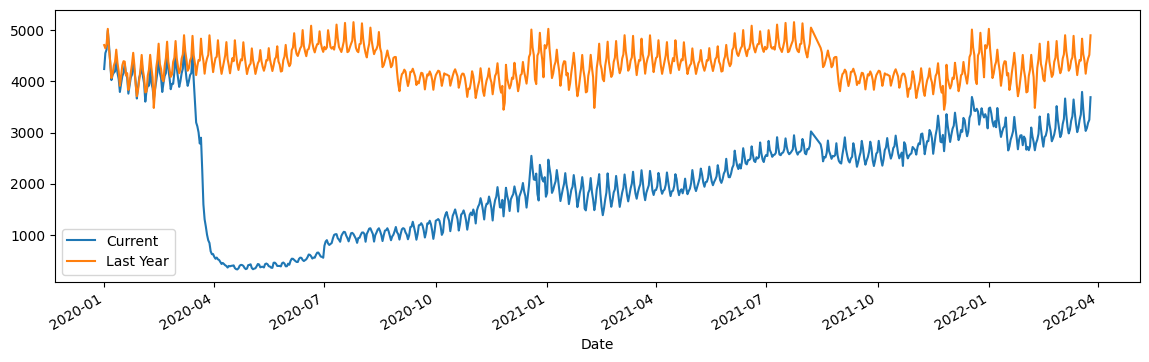

In [154]:
serie_inter = series['U.S. International Commercial Flights (Departures)']
rango_inter = pd.date_range(start = serie_inter.index.min(), end = serie_inter.index.max(), freq = 'D')
print(rango_inter.difference(serie_inter.index))

serie_inter.plot(figsize = (14, 4))

# Como no hay valores extremos se puede interpolar esos valroes faltantes

In [155]:
serie_inter = serie_inter.reindex(rango_inter)

serie_inter['Current'] = serie_inter['Current'].interpolate(method='nearest')
serie_inter['Last Year'] = serie_inter['Last Year'].interpolate(method = 'nearest')

print(serie_inter.isna().sum())
print(len(serie_inter))

Current      0
Last Year    0
dtype: int64
816
